#Домашнаяя контрольная работа 3

###Подключаемся к своему диску и распаковываем архивированный датасет в корневой каталог /content

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
!ls /content


birds_dataset  drive  sample_data


In [ ]:
!unzip -q /content/drive/MyDrive/LAB3/MyDataseet/BIRD.v1i.yolov8.zip -d /content/birds_dataset


###Далее замечаем, что у нашего датасета есть различные классивикации птиц - подправим под один классивикацию

In [ ]:
!ls /content/birds_dataset
!find /content/birds_dataset -maxdepth 2 -type d

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid
/content/birds_dataset
/content/birds_dataset/train
/content/birds_dataset/train/labels
/content/birds_dataset/train/images
/content/birds_dataset/valid
/content/birds_dataset/valid/labels
/content/birds_dataset/valid/images
/content/birds_dataset/test
/content/birds_dataset/test/labels
/content/birds_dataset/test/images


In [ ]:
!ls /content/birds_dataset/train/labels | head
!head -n 3 /content/birds_dataset/train/labels/$(ls /content/birds_dataset/train/labels | head -n 1)


001_jpg.rf.2841cd49ad544631c6dc2d4fa98af1b1.txt
001_jpg.rf.84cbc1be40cbeda73c0f1a0aa536e512.txt
001_jpg.rf.8cfeb10db8dd6c03ca77103e77086a2b.txt
001_jpg.rf.9828e70a7b65da234c6ba3fd630b5eac.txt
001_jpg.rf.b961925b0f860931c291e3f40955793b.txt
001_jpg.rf.d3fb616383ce1de050e87f6a257fd842.txt
002_jpg.rf.48eacbb3772c7246eb4b47a12f014910.txt
002_jpg.rf.a72db1607d30ad9244807d96ab590dc3.txt
002_jpg.rf.d91fdb996b710e0efa42910ea71014ae.txt
002_jpg.rf.dbcd38500d9f46d3ac194d1012b26366.txt
1 0.44765625 0.5125 0.875 0.97421875

In [ ]:
!cat /content/birds_dataset/data.yaml


train: ../train/images
val: ../valid/images
test: ../test/images

nc: 4
names: ['Birds - v1 2023-05-13 1-29pm', 'bird', 'bird - v2 2022-11-08 9-06pm', 'birds']

roboflow:
  workspace: harami-rdknl
  project: bird-ot8oa
  version: 1
  license: Public Domain
  url: https://universe.roboflow.com/harami-rdknl/bird-ot8oa/dataset/1

###Далее две ячейки кода позволяют прверватить датасет в один класс `птицы`

In [ ]:
import glob, os

def remap_labels(folder, keep_class=1):
    for p in glob.glob(os.path.join(folder, "*.txt")):
        new_lines = []
        with open(p, "r") as f:
            for line in f:
                parts = line.strip().split()
                if not parts:
                    continue
                cls = int(float(parts[0]))
                if cls == keep_class:
                    parts[0] = "0"  # делаем единственный класс 0
                    new_lines.append(" ".join(parts))
        with open(p, "w") as f:
            f.write("\n".join(new_lines) + ("\n" if new_lines else ""))

for split in ["train", "valid", "test"]:
    remap_labels(f"/content/birds_dataset/{split}/labels", keep_class=1)

print("Готово: оставили только класс 1 и переобозначили его как 0.")


Готово: оставили только класс 1 и переобозначили его как 0.


In [ ]:
%%writefile /content/birds_dataset/data.yaml
path: /content/birds_dataset
train: train/images
val: valid/images
test: test/images

nc: 1
names: ['bird']


Overwriting /content/birds_dataset/data.yaml


In [ ]:
!cat /content/birds_dataset/data.yaml


path: /content/birds_dataset
train: train/images
val: valid/images
test: test/images

nc: 1
names: ['bird']


###Далее устанавливаем архитектуру YOLO и запускаем процесс обучения

In [ ]:
!pip install -q ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 27.0 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")
model.train(
    data="/content/birds_dataset/data.yaml",
    epochs=30,
    imgsz=640,
    batch=16
)


Ultralytics 8.3.241 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/birds_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, p

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ba6ec9c6990>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

###Рассмотрим теперь часть 4 - графики и метрики

####Графики обучения:

###Total Loss (Classification + Localization)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

csv_path = "runs/detect/train/results.csv"
df = pd.read_csv(csv_path)
df.columns = [c.strip() for c in df.columns]  # иногда пробелы в названиях

print(df.columns.tolist())
df.tail()


['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
25,26,563.570,0.49242,0.42922,1.36336,0.96983,0.96906,0.98744,0.77524,0.72406,0.43384,1.48907,0.000350,0.000350,0.000350
26,27,584.525,0.49861,0.32589,1.37573,0.99226,0.97487,0.99290,0.80340,0.69277,0.40902,1.41394,0.000284,0.000284,0.000284
27,28,603.989,0.47849,0.31596,1.35960,0.97013,0.97928,0.99197,0.80196,0.68880,0.41017,1.42234,0.000218,0.000218,0.000218
28,29,624.810,0.45243,0.35486,1.31132,0.96452,0.99497,0.99314,0.80991,0.65097,0.39784,1.39709,0.000152,0.000152,0.000152
29,30,644.383,0.46626,0.31665,1.34531,0.97864,0.97990,0.99288,0.80629,0.65937,0.38789,1.39587,0.000086,0.000086,0.000086


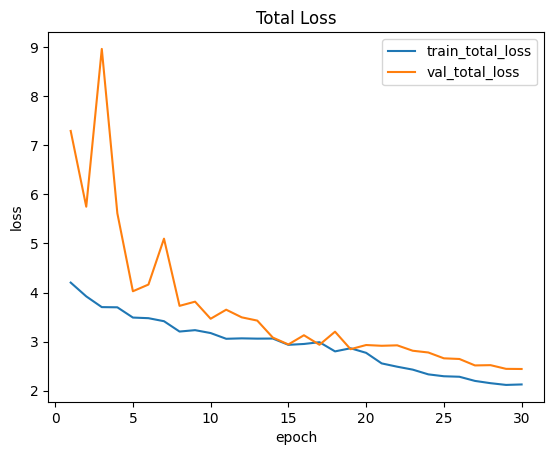

In [ ]:
df["train_total_loss"] = df["train/box_loss"] + df["train/cls_loss"] + df["train/dfl_loss"]
df["val_total_loss"]   = df["val/box_loss"]   + df["val/cls_loss"]   + df["val/dfl_loss"]

plt.figure()
plt.plot(df["epoch"], df["train_total_loss"], label="train_total_loss")
plt.plot(df["epoch"], df["val_total_loss"], label="val_total_loss")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.title("Total Loss")
plt.show()


###Classification Loss отдельно

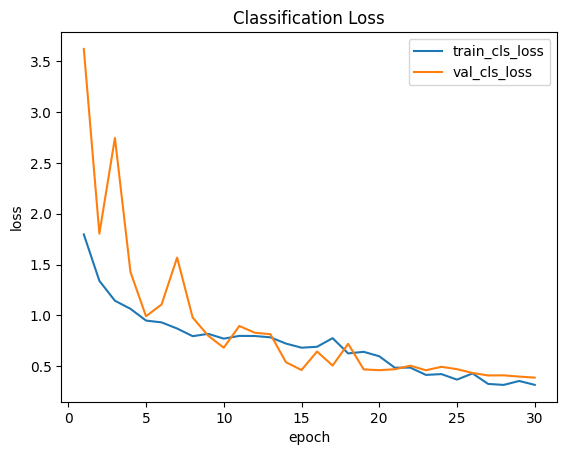

In [ ]:
plt.figure()
plt.plot(df["epoch"], df["train/cls_loss"], label="train_cls_loss")
plt.plot(df["epoch"], df["val/cls_loss"], label="val_cls_loss")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.title("Classification Loss")
plt.show()


###Localization Loss отдельно

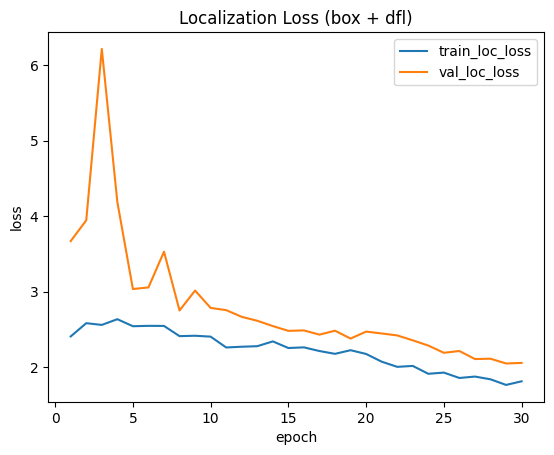

In [ ]:
df["train_loc_loss"] = df["train/box_loss"] + df["train/dfl_loss"]
df["val_loc_loss"]   = df["val/box_loss"]   + df["val/dfl_loss"]

plt.figure()
plt.plot(df["epoch"], df["train_loc_loss"], label="train_loc_loss")
plt.plot(df["epoch"], df["val_loc_loss"], label="val_loc_loss")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.title("Localization Loss (box + dfl)")
plt.show()


###mAP по эпохам

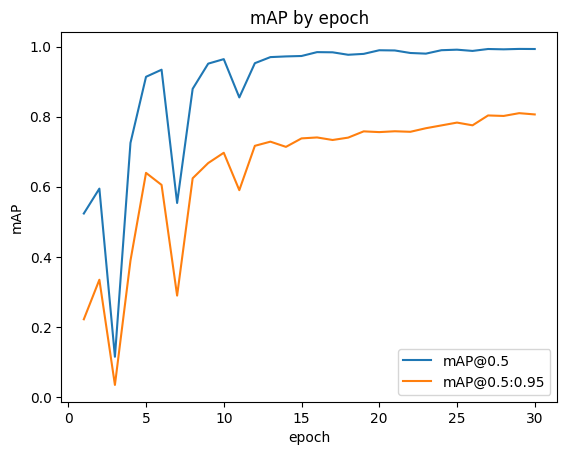

In [ ]:
plt.figure()
plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP@0.5")
plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP@0.5:0.95")
plt.xlabel("epoch"); plt.ylabel("mAP"); plt.legend(); plt.title("mAP by epoch")
plt.show()


##Метрики на тестовом выборе

In [ ]:
from ultralytics import YOLO

model = YOLO("runs/detect/train/weights/best.pt")
metrics = model.val(data="/content/birds_dataset/data.yaml", split="test", iou=0.5)
metrics


Ultralytics 8.3.241 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 345.1±101.8 MB/s, size: 41.0 KB)
val: Scanning /content/birds_dataset/test/labels... 145 images, 43 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 145/145 2.0Kit/s 0.1s
val: New cache created: /content/birds_dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 3.5it/s 2.9s
                   all        145        102      0.971      0.998      0.995      0.799
Speed: 4.0ms preprocess, 5.6ms inference, 0.0ms loss, 2.0ms postprocess per image
Results saved to /content/runs/detect/val


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ba6ecc64f80>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [ ]:
# Общие метрики
try:
    print("mAP@0.5:", metrics.box.map50)
    print("mAP@0.5:0.95:", metrics.box.map)
    print("Precision:", metrics.box.mp)   # mean precision
    print("Recall:", metrics.box.mr)      # mean recall
except Exception as e:
    print("Не смог прочитать через metrics.box.*:", e)
    print(metrics)


mAP@0.5: 0.9945162659123056
mAP@0.5:0.95: 0.7988974315779
Precision: 0.9713667860345963
Recall: 0.9977951094699076


###Примеры предсказаний:

####Сделаем предикт на test/images и сохраним результаты

In [ ]:
model = YOLO("runs/detect/train/weights/best.pt")
model.predict(
    source="/content/birds_dataset/test/images",
    conf=0.25,
    iou=0.5,
    save=True
)



image 1/145 /content/birds_dataset/test/images/-_jpg.rf.a0c7696c3b8a2aff7e98da6d0950fbe0.jpg: 640x640 (no detections), 8.2ms
image 2/145 /content/birds_dataset/test/images/001_jpg.rf.c832980ba4a4f9ce334efd645534ec81.jpg: 640x640 1 bird, 7.2ms
image 3/145 /content/birds_dataset/test/images/002_jpg.rf.c79f7223468831b3f4564dcef587d682.jpg: 640x640 1 bird, 7.3ms
image 4/145 /content/birds_dataset/test/images/003_jpg.rf.4582c586a56adedb79ac3087352d9400.jpg: 640x640 1 bird, 7.3ms
image 5/145 /content/birds_dataset/test/images/005_jpg.rf.3d075723306c83d4b2fccd81d88d4d9d.jpg: 640x640 1 bird, 7.2ms
image 6/145 /content/birds_dataset/test/images/007_jpg.rf.d42bde478014a4c454a9620f9226b21e.jpg: 640x640 1 bird, 7.3ms
image 7/145 /content/birds_dataset/test/images/008_jpg.rf.1b73bb171ef7a9489a87f1ca461b3ada.jpg: 640x640 1 bird, 7.2ms
image 8/145 /content/birds_dataset/test/images/008_jpg.rf.9c69c7ff44fb9be0baee45ccce54647a.jpg: 640x640 1 bird, 7.2ms
image 9/145 /content/birds_dataset/test/images/0

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'bird'}
 obb: None
 orig_img: array([[[136,  79,  18],
         [136,  79,  18],
         [136,  79,  18],
         ...,
         [139,  81,  22],
         [140,  82,  23],
         [141,  83,  24]],
 
        [[136,  79,  18],
         [136,  79,  18],
         [136,  79,  18],
         ...,
         [139,  81,  22],
         [140,  82,  23],
         [141,  83,  24]],
 
        [[136,  79,  18],
         [136,  79,  18],
         [136,  79,  18],
         ...,
         [139,  81,  22],
         [140,  82,  23],
         [141,  83,  24]],
 
        ...,
 
        [[157,  95,  35],
         [157,  95,  35],
         [157,  95,  35],
         ...,
         [154,  96,  44],
         [153,  95,  43],
         [152,  94,  42]],
 
        [[157,  95,  35],
         [157,  95,  35],
         [157,  95,  35],
         ...,
         [154,  96, 

####Сохраняем работу

In [ ]:
import glob
pred_dirs = sorted(glob.glob("runs/detect/predict*"), key=lambda x: x)
pred_dirs[-1]


'runs/detect/predict'

####Выбираем 12 случайных фотографий

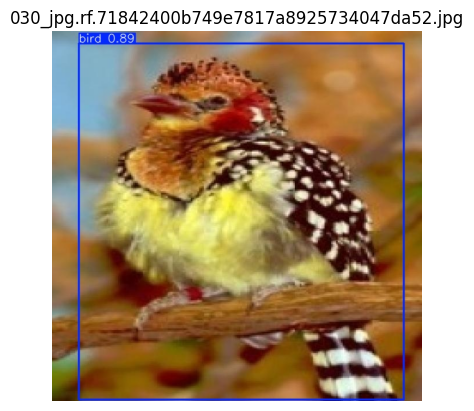

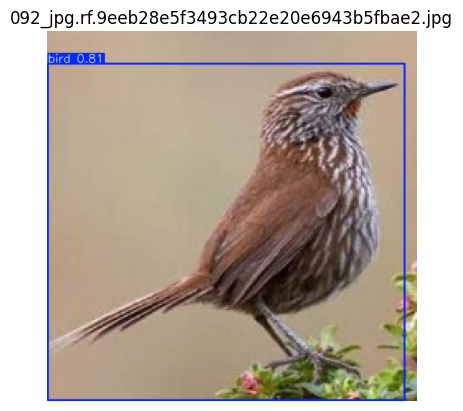

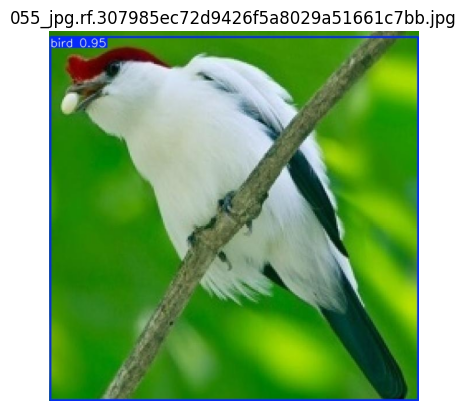

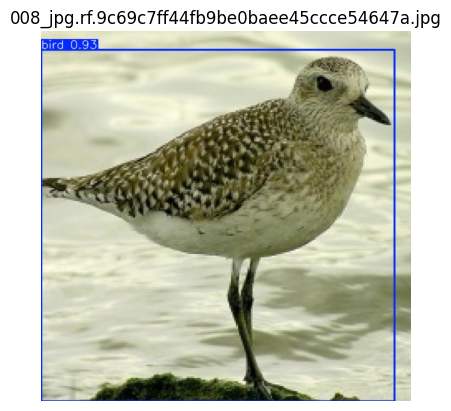

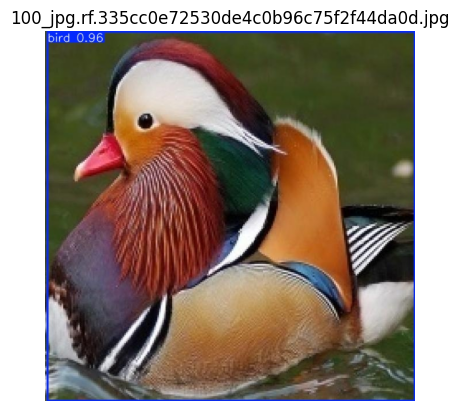

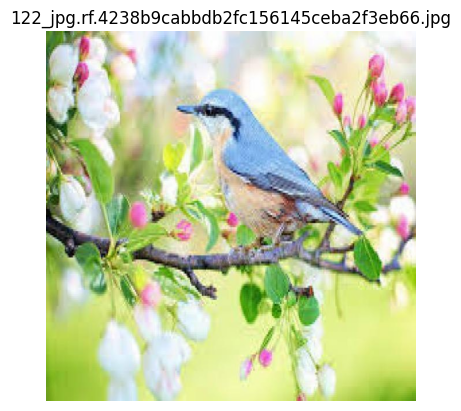

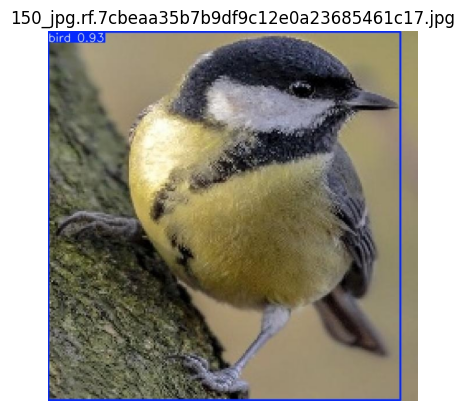

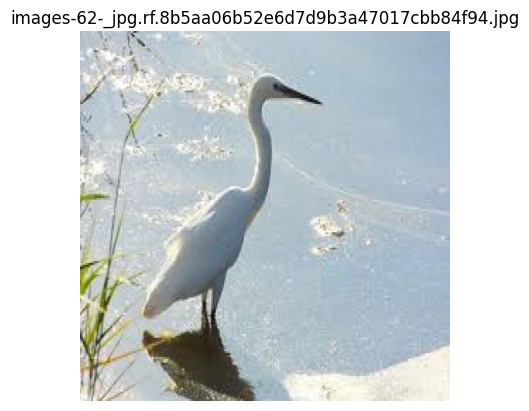

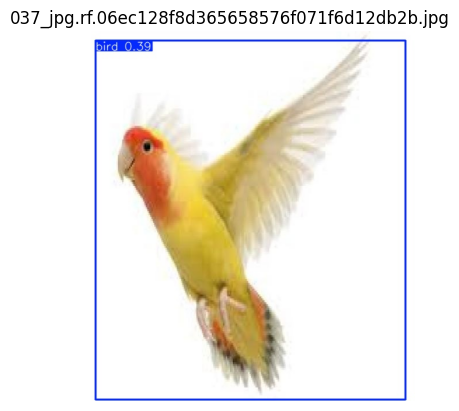

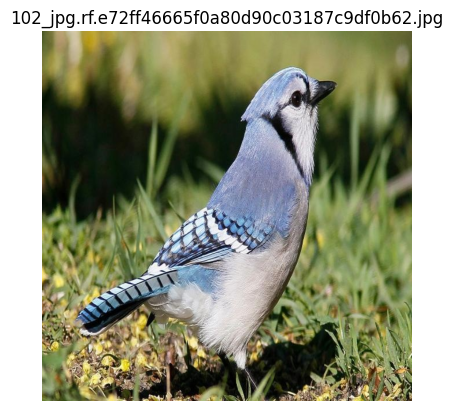

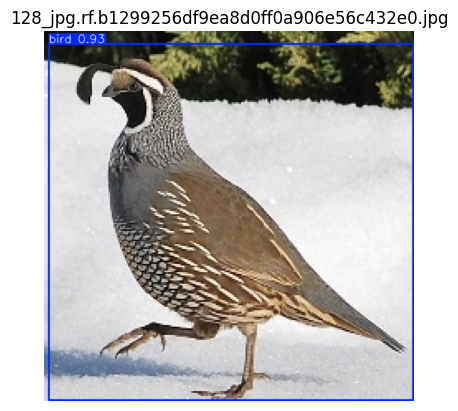

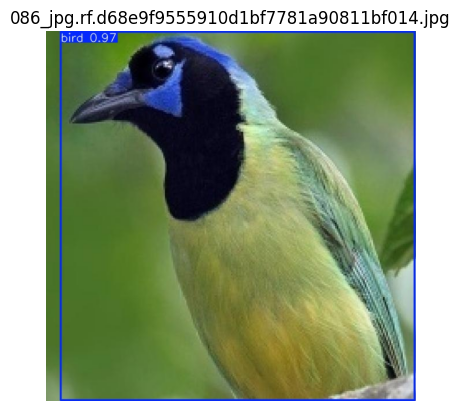

In [ ]:
import os, random
from PIL import Image
import matplotlib.pyplot as plt

pred_dir = pred_dirs[-1]
imgs = glob.glob(os.path.join(pred_dir, "*.jpg")) + glob.glob(os.path.join(pred_dir, "*.png"))
random.shuffle(imgs)

show_n = 12
for p in imgs[:show_n]:
    plt.figure()
    plt.imshow(Image.open(p))
    plt.axis("off")
    plt.title(os.path.basename(p))
    plt.show()


###Прогоняем видео птиц и делаем отметки на объекты

####Прогнать видео через модель и получить “размеченное” видео

####Здесь мы прогоняем видео через модель и должны получить `размеченное видео`
####Т.е. происходит инференс на видео

In [ ]:
from ultralytics import YOLO
from pathlib import Path
from glob import glob

print(glob("runs/detect/**/weights/best.pt", recursive=True))

weights = Path("runs/detect/train/weights/best.pt")
video_path = Path("/content/drive/MyDrive/LAB3/videos/video.mp4")

assert weights.exists(), f"Не найден файл весов: {weights}"
assert video_path.exists(), f"Не найдено видео: {video_path}"

model = YOLO(str(weights))

results = model.predict(
    source=str(video_path),
    conf=0.2,
    iou=0.5,
    save=True,
    project="runs/detect",
    name="predict_video",
    show_labels=True,
    show_conf=True,
    line_width=2,
)

out_dir = Path(results[0].save_dir)
print("save_dir:", out_dir)
print("files:", list(out_dir.glob("*")))

videos = list(out_dir.glob("*.mp4")) + list(out_dir.glob("*.avi")) + list(out_dir.glob("*.mov"))
print("saved videos:", videos)

print("frames:", len(results))
print("first frame boxes:", len(results[0].boxes))
if len(results[0].boxes):
    print("first scores:", results[0].boxes.conf[:10].tolist())


['runs/detect/train/weights/best.pt', 'runs/detect/train2/weights/best.pt']

WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/603) /content/drive/MyDrive/LAB3/videos/video.mp4: 384x640 1 bird, 6.6ms
video 1/1 (frame 2/603) /content/drive/MyDrive/LAB3/videos/video.mp4: 384x640 1 bird, 8.5ms
video 1/1 (frame 3/603) /content/drive/MyDrive/LAB3/videos/video.mp4: 384x640 1 bird, 7.3ms
video 1/1 (frame 4/603) /content/drive/MyDrive/LAB3/videos/video.mp4: 384x640 1 bird, 8.3ms
video 1/1 (fra

In [ ]:
!ls /content/runs/detect/predict_video/

3594308-hd_1920_1080_30fps.avi


In [ ]:
from pathlib import Path
import shutil

src = Path("/content/runs/detect/predict_video5/video.avi")
dst = Path("/content/drive/MyDrive/LAB3/predict_video/video.avi")
dst.parent.mkdir(parents=True, exist_ok=True)
shutil.copy2(src, dst)
print("Скопировано в:", dst)


Скопировано в: /content/drive/MyDrive/LAB3/predict_video/video.avi


In [ ]:
from ultralytics import YOLO
from pathlib import Path

model = YOLO("runs/detect/train/weights/best.pt")

src_videos = Path("/content/drive/MyDrive/LAB3/videos").glob("*.mp4")
project = Path("/content/runs/detect")

for video in src_videos:
    run_name = f"predict_{video.stem}"

    results = model.predict(
        source=str(video),
        conf=0.2,
        iou=0.5,
        save=True,
        stream=True,
        project=str(project),
        name=run_name,
        exist_ok=True,     # ✅ перезаписывает ТОЛЬКО ЭТУ папку, а не плодит predict_video2/3/4
    )

    # обязательно пройти генератор
    last = None
    for r in results:
        last = r

    out_dir = Path(last.save_dir) if last is not None else (project / run_name)
    print("OK:", video.name, "->", out_dir)



video 1/1 (frame 1/603) /content/drive/MyDrive/LAB3/videos/video2.mp4: 384x640 1 bird, 18.8ms
video 1/1 (frame 2/603) /content/drive/MyDrive/LAB3/videos/video2.mp4: 384x640 1 bird, 15.9ms
video 1/1 (frame 3/603) /content/drive/MyDrive/LAB3/videos/video2.mp4: 384x640 1 bird, 9.0ms
video 1/1 (frame 4/603) /content/drive/MyDrive/LAB3/videos/video2.mp4: 384x640 1 bird, 15.9ms
video 1/1 (frame 5/603) /content/drive/MyDrive/LAB3/videos/video2.mp4: 384x640 1 bird, 18.4ms
video 1/1 (frame 6/603) /content/drive/MyDrive/LAB3/videos/video2.mp4: 384x640 1 bird, 15.8ms
video 1/1 (frame 7/603) /content/drive/MyDrive/LAB3/videos/video2.mp4: 384x640 1 bird, 20.2ms
video 1/1 (frame 8/603) /content/drive/MyDrive/LAB3/videos/video2.mp4: 384x640 1 bird, 20.7ms
video 1/1 (frame 9/603) /content/drive/MyDrive/LAB3/videos/video2.mp4: 384x640 1 bird, 7.8ms
video 1/1 (frame 10/603) /content/drive/MyDrive/LAB3/videos/video2.mp4: 384x640 1 bird, 9.4ms
video 1/1 (frame 11/603) /content/drive/MyDrive/LAB3/videos/v

In [ ]:
import shutil
from pathlib import Path

dst_root = Path("/content/drive/MyDrive/LAB3/predict_results")
dst_root.mkdir(parents=True, exist_ok=True)

project = Path("/content/runs/detect")

for run_dir in project.glob("predict_*"):
    # ищем любой видеофайл
    vids = list(run_dir.glob("*.avi")) + list(run_dir.glob("*.mp4")) + list(run_dir.glob("*.mov"))
    if not vids:
        print("⚠ нет видео в", run_dir.name)
        continue

    # берём самый свежий по времени изменения
    v = max(vids, key=lambda p: p.stat().st_mtime)

    # чтобы сразу видеть, что не копируется одна и та же хрень — добавим размер
    size_mb = v.stat().st_size / (1024**2)

    dst = dst_root / f"{run_dir.name}{v.suffix}"
    shutil.copy2(v, dst)
    print(f"✔ {run_dir.name}: {v.name} ({size_mb:.1f} MB) -> {dst.name}")


✔ predict_video11: video.avi (73.3 MB) -> predict_video11.avi
✔ predict_video32: video3.avi (32.9 MB) -> predict_video32.avi
✔ predict_video: 3594308-hd_1920_1080_30fps.avi (310.2 MB) -> predict_video.avi
✔ predict_video3: video3.avi (34.6 MB) -> predict_video3.avi
✔ predict_video22: video2.avi (73.3 MB) -> predict_video22.avi
✔ predict_video6: video2.avi (73.3 MB) -> predict_video6.avi
✔ predict_video8: video3.avi (32.9 MB) -> predict_video8.avi
✔ predict_video7: video3.avi (32.9 MB) -> predict_video7.avi
✔ predict_video2: video2.avi (74.8 MB) -> predict_video2.avi
✔ predict_video4: 3594308-hd_1920_1080_30fps.avi (173.0 MB) -> predict_video4.avi
✔ predict_video10: video.avi (170.7 MB) -> predict_video10.avi
✔ predict_video5: video.avi (170.7 MB) -> predict_video5.avi
✔ predict_video33: video3.avi (32.9 MB) -> predict_video33.avi
✔ predict_video9: video.avi (170.7 MB) -> predict_video9.avi
